# 05 — flybody

The brain steering Janelia's anatomical fruit fly, which flies on its own wings. Read `docs/05-flybody.md` alongside.
Needs flybody's trained flight policy under `data/flybody/` (see the doc) and TensorFlow (CPU).

In [1]:
import os, sys; sys.path.insert(0, "..")
os.environ["FLYVIS_ROOT_DIR"] = os.path.abspath("../data/flyvis")
os.environ.setdefault("MUJOCO_GL", "glfw")
import numpy as np, polars as pl, mujoco
from flyhigh.data.connectome import Connectome
from flyhigh.agent import FlyAgent
from flyhigh.motor.command import MotorCommand
from flyhigh.motor.readout import ReadoutParams
from flyhigh.flybody.sim import FlySimulation
import matplotlib as mpl, matplotlib.pyplot as plt
# dataviz conventions: fixed categorical order, single-hue sequential, thin marks, recessive grid
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.prop_cycle": mpl.cycler(color=C), "lines.linewidth": 2, "font.size": 10})
os.chdir("..")  # flybody's policy and wing pattern are addressed from the repo root
c = Connectome.load("data/raw")
agent = FlyAgent(c, n_agents=1, params=ReadoutParams(forward_bias=0.0))
sim = FlySimulation(agent)
print(f"drum {sim.drum.size} cm, {sim.policy_per_tick} policy steps per 10 ms tick, wing beat {sim.log()['wingbeat_hz'][-1] if sim.rows else 218:.0f} Hz")

/home/martin/dev_works/Side_Projects/Flyhigh/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-09-21 11:58:44] __init__:88 MUJOCO_GL=glfw, attempting to import specified OpenGL backend.


[2026-09-21 11:58:45] __init__:31 MuJoCo library version is: 3.13.0


[2026-09-21 11:58:48] network_view:122 Initialized network view at /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000


[2026-09-21 11:58:48] logging_utils:23 epe not in /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000/validation, but 'loss' is. Falling back to 'loss'. You can rerun the ensemble validation to make appropriate recordings of the losses.


...

[2026-09-21 11:58:54] chkpt_utils:36 Recovered network state.


/home/martin/dev_works/Side_Projects/Flyhigh/.venv/lib/python3.12/site-packages/tensorflow_probability/python/__init__.py:57: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if (distutils.version.LooseVersion(tf.__version__) <
/home/martin/dev_works/Side_Projects/Flyhigh/.venv/lib/python3.12/site-packages/tensorflow_probability/python/__init__.py:58: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  distutils.version.LooseVersion(required_tensorflow_version)):


W0000 00:00:1789984738.775925   30601 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
[2026-09-21 11:58:58] load:1083 Fingerprint not found. Saved model loading will continue.


[2026-09-21 11:58:58] load:1102 path_and_singleprint metric could not be logged. Saved model loading will continue.


drum (30.0, 30.0, 15.0) cm, 50 policy steps per 10 ms tick, wing beat 218 Hz


## 1. The fly's-eye view and the fly
Fly-scale drum: striped side walls, the fingertip ahead-right.

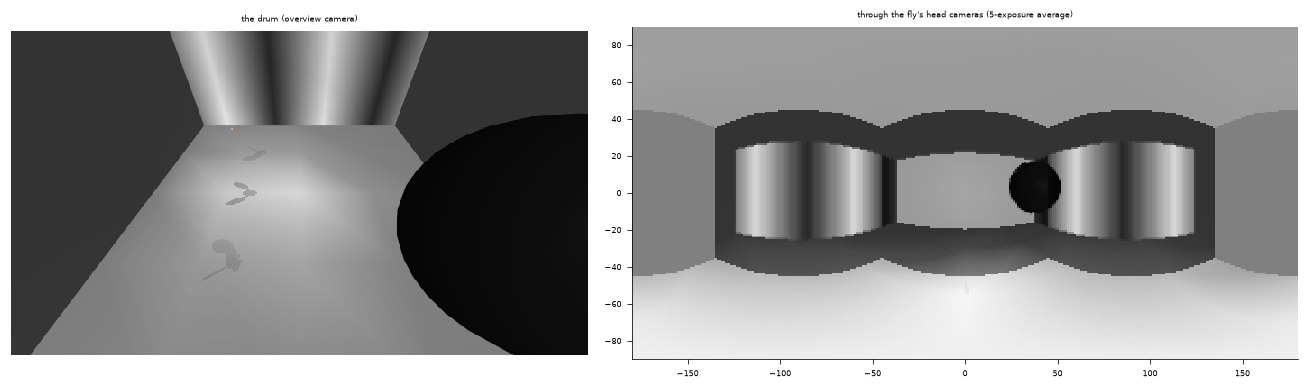

In [2]:
over = mujoco.Renderer(sim.physics.model.ptr, 360, 640); over.update_scene(sim.physics.data.ptr, camera="overview"); top = over.render(); over.close()
pano = sim.frames()[0].lum
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.3, 1.5]})
axes[0].imshow(top); axes[0].set_title("the drum (overview camera)"); axes[0].axis("off")
axes[1].imshow(pano, cmap="gray", vmin=0, vmax=1, extent=[-180, 180, -90, 90]); axes[1].set_title("through the fly's head cameras (5-exposure average)"); axes[1].grid(False)
plt.tight_layout()

## 2. The hand
A 4 cm fingertip comes at the hovering fly at 50 cm/s. The brain's escape steers the flight controller into a hop.

[2026-09-21 11:59:51] environment:135 The current episode has been running for 10000 steps.


first escape at hand distance 16.93 cm; escape ticks 39


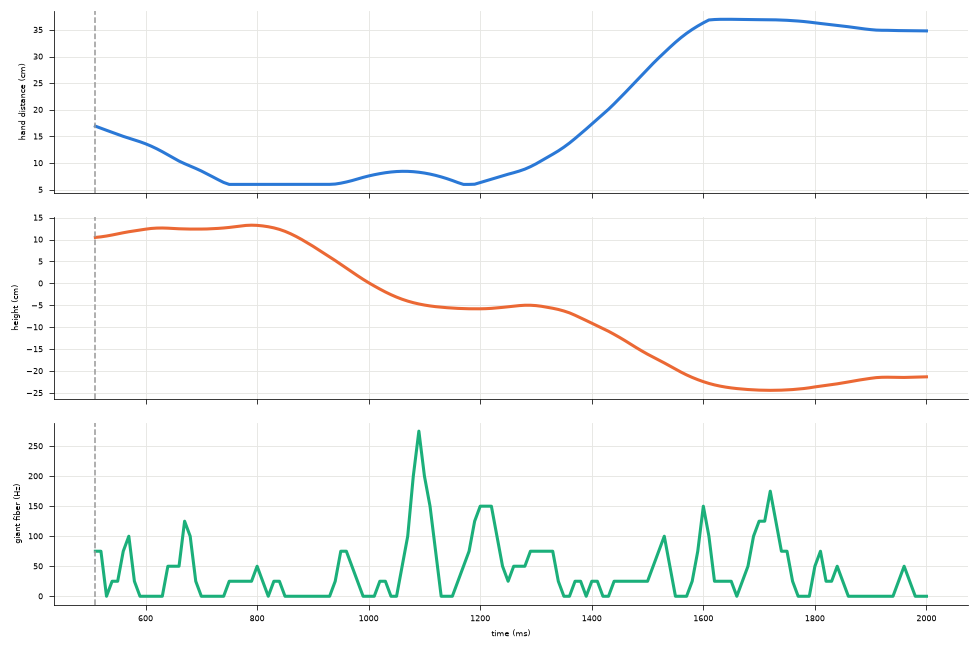

In [3]:
sim.run(0.5)
sim.hand.approach(lambda s=sim: s.pos)
n0 = len(sim.rows); sim.run(1.5); log = pl.DataFrame(sim.rows[n0:])
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(log["t_ms"], log["hand_dist"], color=C[0]); axes[0].set_ylabel("hand distance (cm)")
axes[1].plot(log["t_ms"], log["z"], color=C[1]); axes[1].set_ylabel("height (cm)")
axes[2].plot(log["t_ms"], log["gf_hz"], color=C[2]); axes[2].set_ylabel("giant fiber (Hz)"); axes[2].set_xlabel("time (ms)")
for ax in axes:
    for t in log.filter(pl.col("escape"))["t_ms"][:1]: ax.axvline(t, color="#999", lw=1, ls="--")
plt.tight_layout()
e = log.filter(pl.col("escape"))
print("first escape at hand distance", None if e.height == 0 else round(e["hand_dist"][0], 2), "cm; escape ticks", e.height)

## 3. Steering without the brain
The same fly with scripted commands: forward, a turn, a climb, an escape hop. Trajectory from above and height over time.

[2026-09-21 11:59:53] load:1083 Fingerprint not found. Saved model loading will continue.


[2026-09-21 11:59:53] load:1102 path_and_singleprint metric could not be logged. Saved model loading will continue.


[2026-09-21 12:00:29] environment:135 The current episode has been running for 10000 steps.


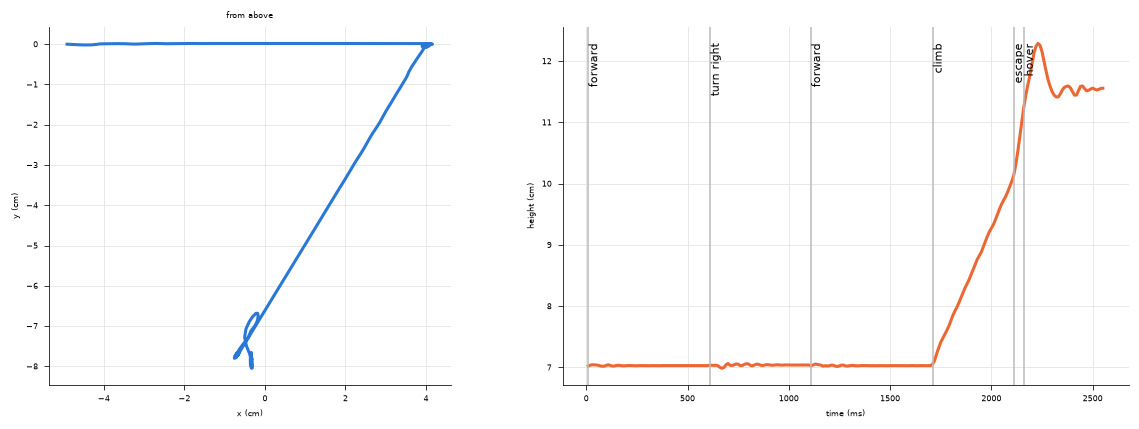

In [4]:
class Scripted:
    def __init__(self): self.cmd = MotorCommand.idle(0.0)
    def tick(self, frames): return [self.cmd]
sim.close(); s2 = FlySimulation(Scripted(), settle_s=0.0)
plan = [(MotorCommand(0.5, 0, 0, False), 0.6, "forward"), (MotorCommand(0, 0.5, 0, False), 0.5, "turn right"),
        (MotorCommand(0.5, 0, 0, False), 0.6, "forward"), (MotorCommand(0, 0, 0.5, False), 0.4, "climb"),
        (MotorCommand(0, 0, 0, True), 0.05, "escape"), (MotorCommand.idle(0.0), 0.4, "hover")]
marks = []
for cmd, secs, label in plan:
    s2.agent.cmd = cmd; marks.append((len(s2.rows), label)); s2.run(secs)
log = s2.log(); s2.close()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log["x"], log["y"], color=C[0]); axes[0].set_aspect("equal"); axes[0].set_xlabel("x (cm)"); axes[0].set_ylabel("y (cm)"); axes[0].set_title("from above")
axes[1].plot(log["t_ms"], log["z"], color=C[1]); axes[1].set_xlabel("time (ms)"); axes[1].set_ylabel("height (cm)")
for i, label in marks:
    axes[1].axvline(log["t_ms"][i], color="#bbb", lw=1); axes[1].text(log["t_ms"][i], log["z"].max(), label, fontsize=7, rotation=90, va="top")
plt.tight_layout()

## Try it
- `SteerParams(escape_up=40)` — the policy tumbles; 20 cm/s is the most it takes.
- `FlySimulation(agent, exposures=1)` — one snapshot per tick: the fly escapes from its own wing-beat jitter.
- `sim.spin_drum = 60` — the optomotor drum; watch HS respond and the giant fiber fire (docs/05 §3).